In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

/tmp/ipython-input-23-430952518.py:5: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



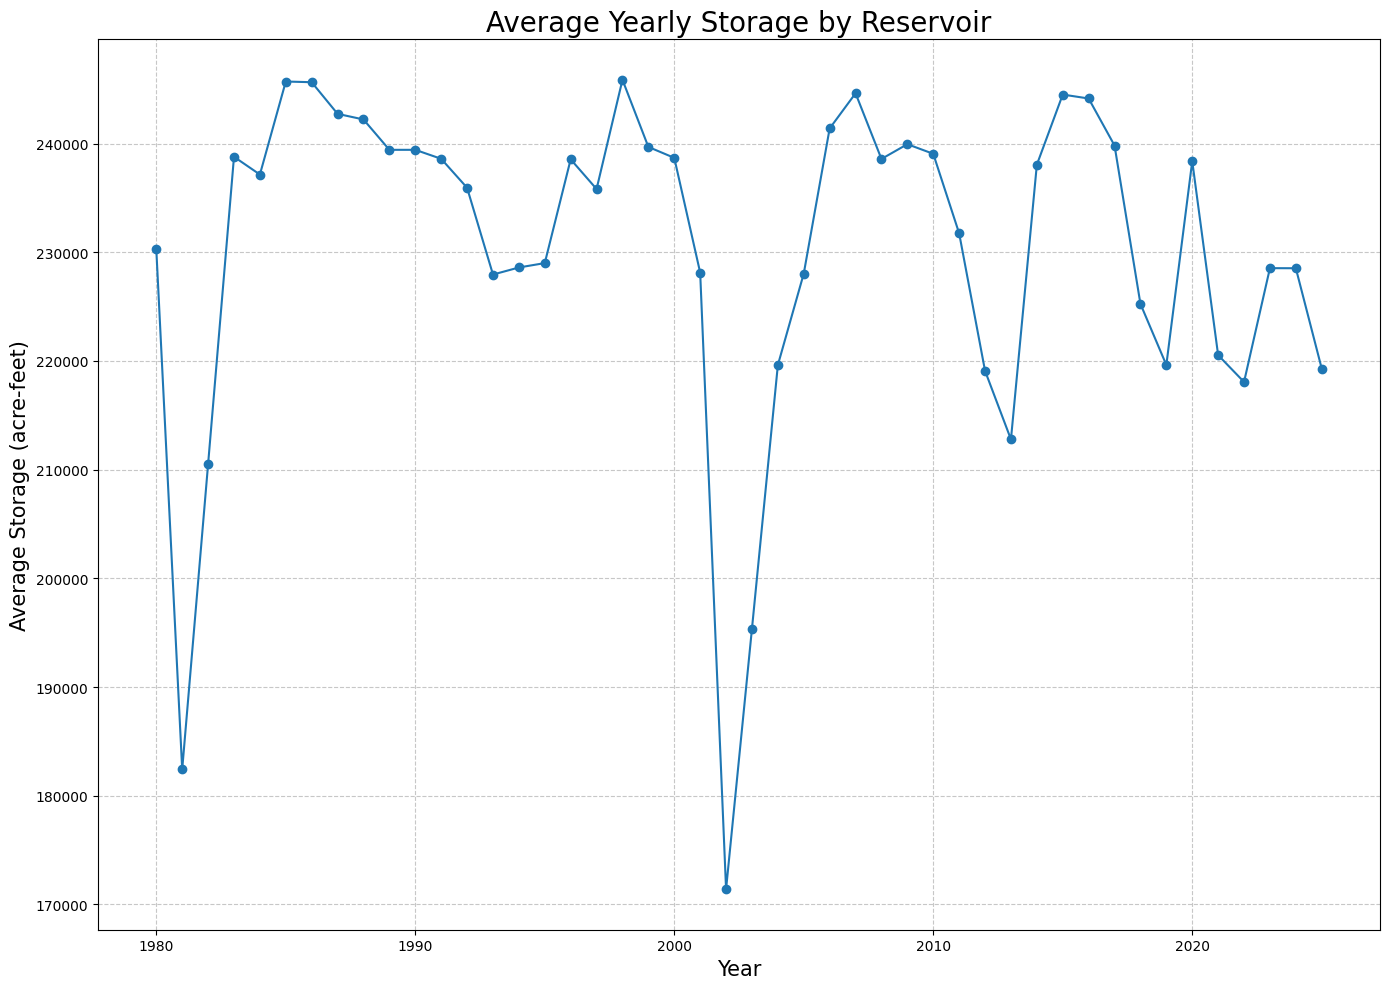

In [ ]:
# Define the processing function
def process_reservoir(filepath, name):
    df = pd.read_csv(filepath)
    df = df[['Date', 'Storage (af)']]
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Storage (af)'] = pd.to_numeric(df['Storage (af)'], errors='coerce')
    df = df.dropna()
    df['Year'] = df['Date'].dt.year
    yearly_avg = df.groupby('Year')['Storage (af)'].mean().reset_index()
    yearly_avg.rename(columns={'Storage (af)': name}, inplace=True)
    return yearly_avg

# Process all reservoirs
reservoirs = {
    'Dillon': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Dillon Reservoir.csv',
    'Blue Mesa': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Blue Mesa Reservoir.csv',
    'Granby': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Granby Reservoir.csv',
    'Green Mountain': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Green Mountain Reservoir.csv',
    'Morrow Point': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Morrow Point Reservoir.csv',
    'Navajo': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Navajo Reservoir.csv',
    'Ruedi': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Ruedi Reservoir.csv',
    'Taylor Park': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Taylor Park Reservoir.csv',
    'Vallecito': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Vallecito Reservoir.csv',
}

# Process and store each yearly average DataFrame
dfs = []
for name, path in reservoirs.items():
    df = process_reservoir(path, name)
    dfs.append(df)

# Merge all reservoirs on 'Year'
from functools import reduce
merged = reduce(lambda left, right: pd.merge(left, right, on='Year', how='outer'), dfs)
merged = merged.sort_values('Year')

# Plot all lines
plt.figure(figsize=(14, 10))
for col in merged.columns[1:]:  # skip 'Year'
    plt.plot(merged['Year'], merged[col], marker='o', label=col)

plt.title('Average Yearly Storage by Reservoir', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Average Storage (acre-feet)', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


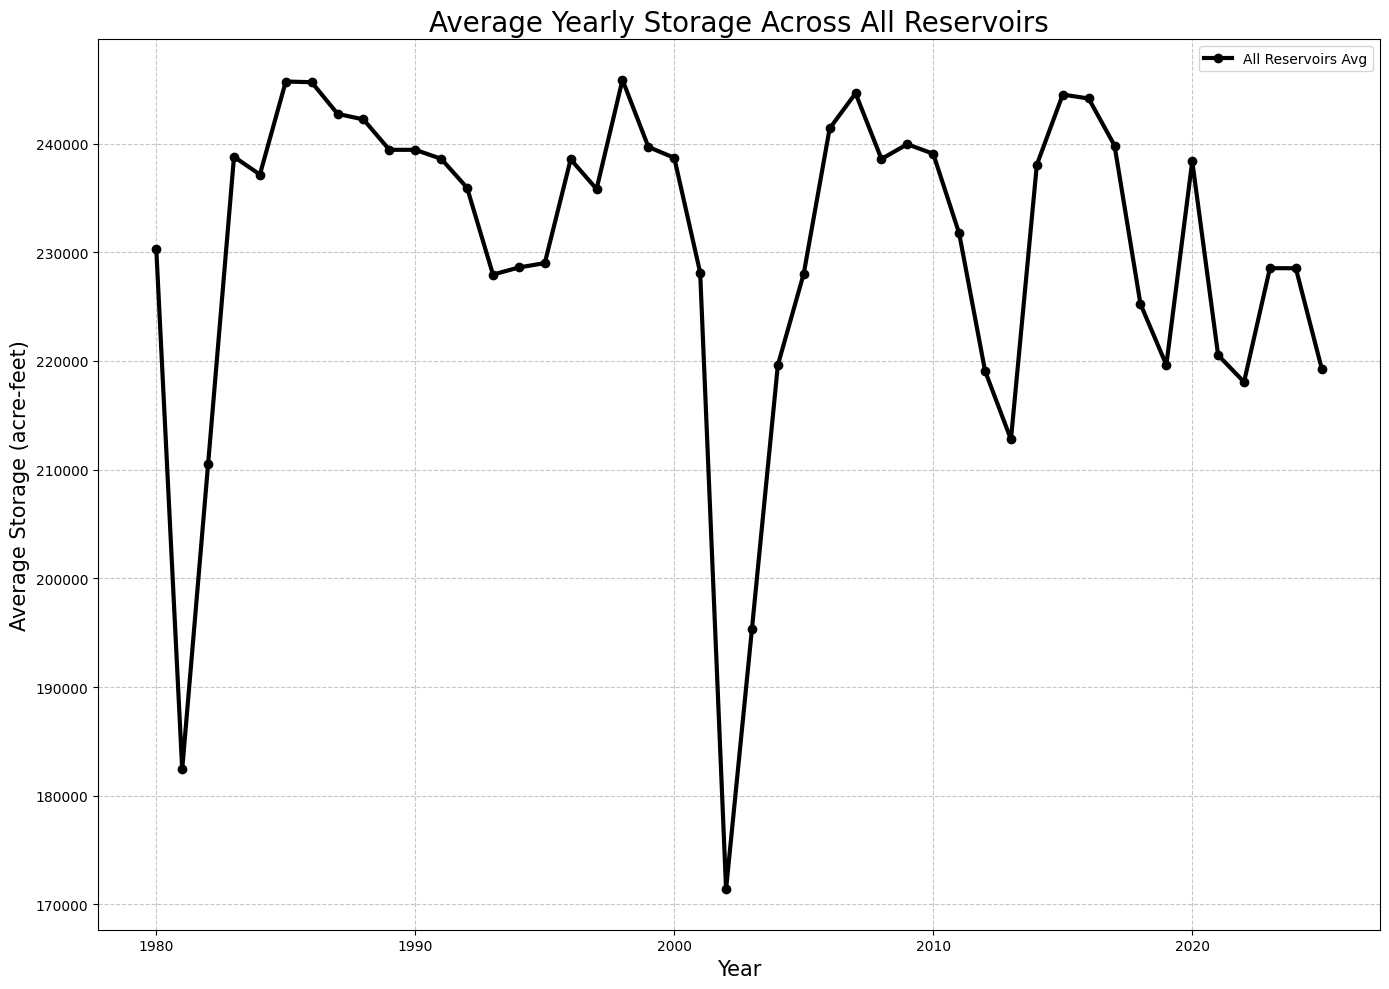

In [ ]:
# Merge all reservoirs on 'Year'
from functools import reduce
merged = reduce(lambda left, right: pd.merge(left, right, on='Year', how='outer'), dfs)
merged = merged.sort_values('Year')

# Calculate average storage across all reservoirs
merged['All Reservoirs Average'] = merged.iloc[:, 1:].mean(axis=1)

# Plot all lines
plt.figure(figsize=(14, 10))

# Plot only the average line
plt.plot(merged['Year'], merged['All Reservoirs Average'], marker='o', color='black', linewidth=3, label='All Reservoirs Avg')

plt.title('Average Yearly Storage Across All Reservoirs', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Average Storage (acre-feet)', fontsize=15)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# create 2 different graphs that display the 1980-2000 data and 2001-2025 data


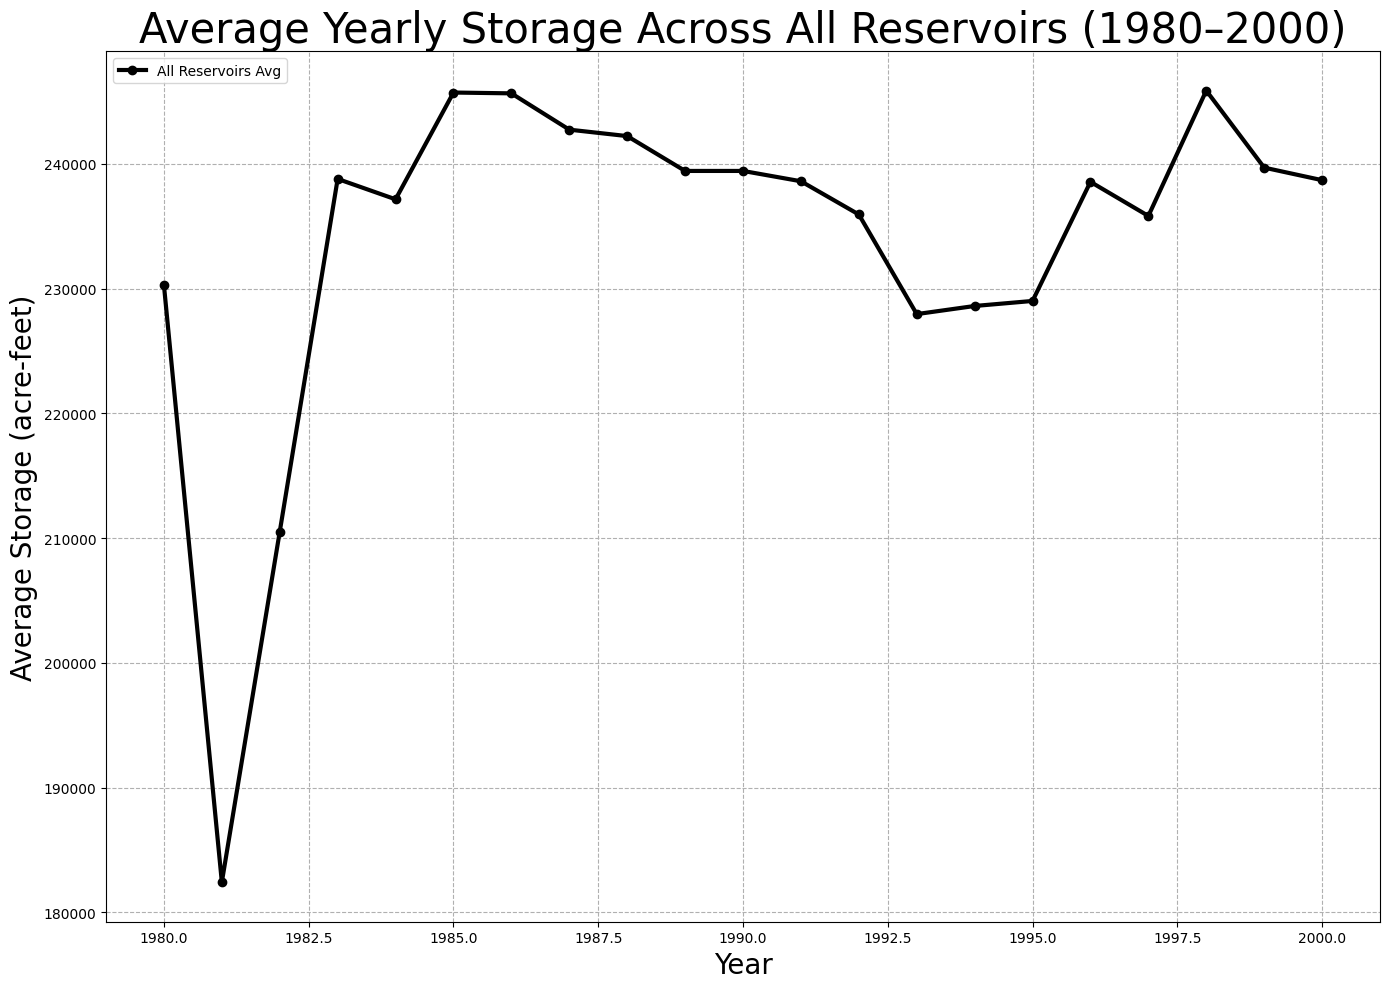

In [ ]:
import matplotlib.pyplot as plt

# Separate data for 1980–2000
merged_1980_2000 = merged[(merged['Year'] >= 1980) & (merged['Year'] <= 2000)]

# Plot only "All Reservoirs Avg"
plt.figure(figsize=(14, 10))

plt.plot(
    merged_1980_2000['Year'],
    merged_1980_2000['All Reservoirs Average'],
    marker='o',
    color='black',
    linewidth=3,
    label='All Reservoirs Avg'
)

# Titles and labels
plt.title('Average Yearly Storage Across All Reservoirs (1980–2000)', fontsize=30)
plt.xlabel('Year', fontsize=20)
plt.ylabel('Average Storage (acre-feet)', fontsize=20)

# Legend
plt.legend(loc='upper left')

# Grid and layout
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()



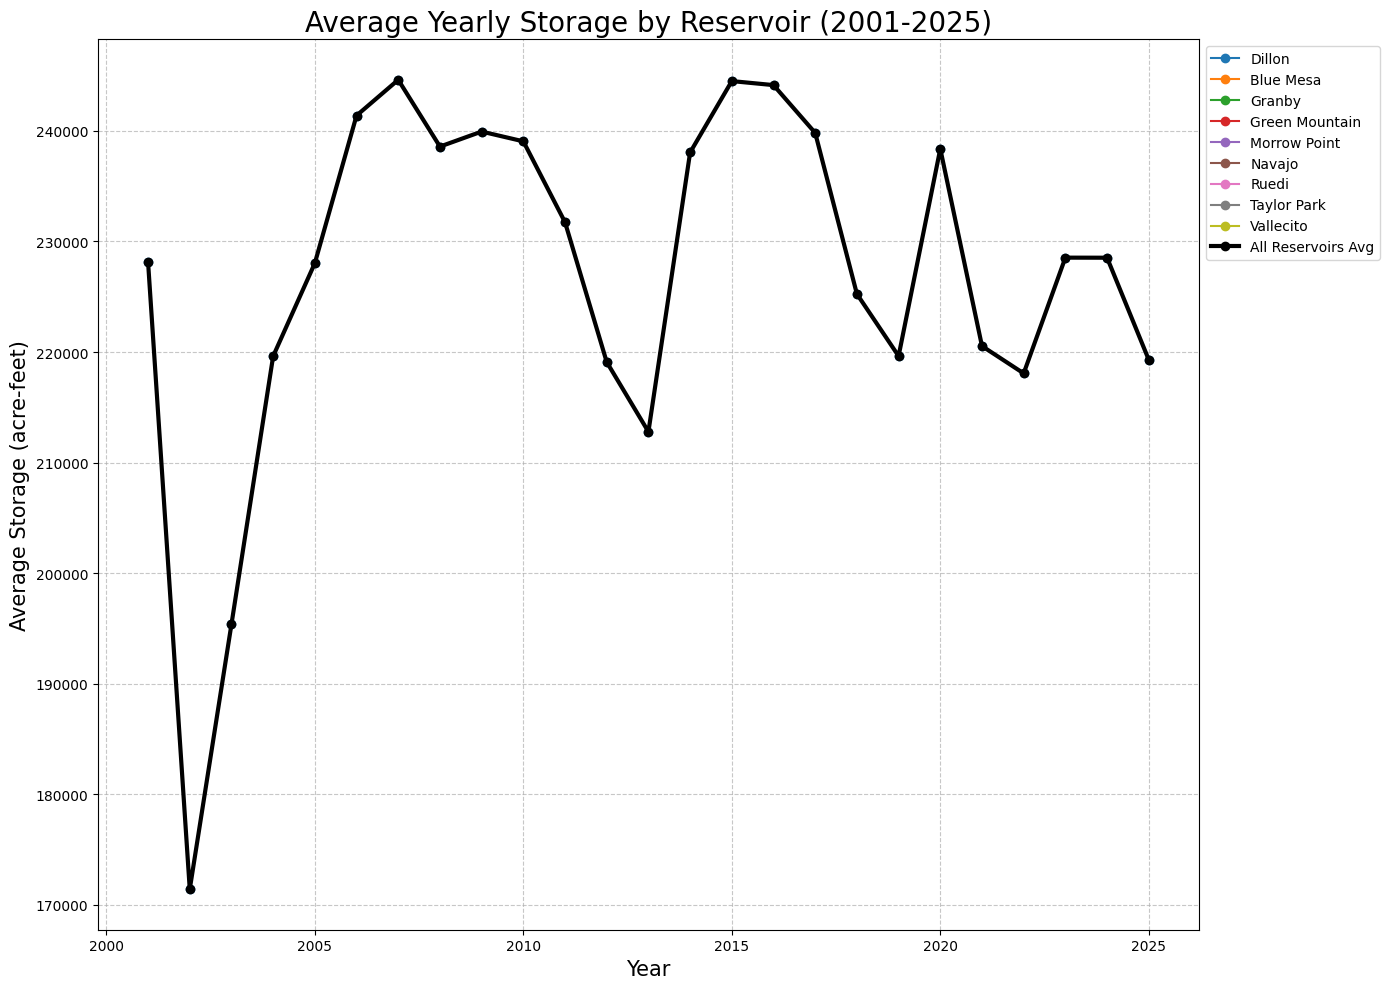

In [ ]:
# Separate data for 2001-2025
merged_2001_2025 = merged[(merged['Year'] >= 2001) & (merged['Year'] <= 2025)]

# Plot data for 2001-2025
plt.figure(figsize=(14, 10))
for col in merged_2001_2025.columns[1:]:  # skip 'Year'
    if col != 'All Reservoirs Average':
        plt.plot(merged_2001_2025['Year'], merged_2001_2025[col], marker='o', label=col)

plt.plot(merged_2001_2025['Year'], merged_2001_2025['All Reservoirs Average'], marker='o', color='black', linewidth=3, label='All Reservoirs Avg')

plt.title('Average Yearly Storage by Reservoir (2001-2025)', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Average Storage (acre-feet)', fontsize=15)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipython-input-28-2938298405.py:5: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



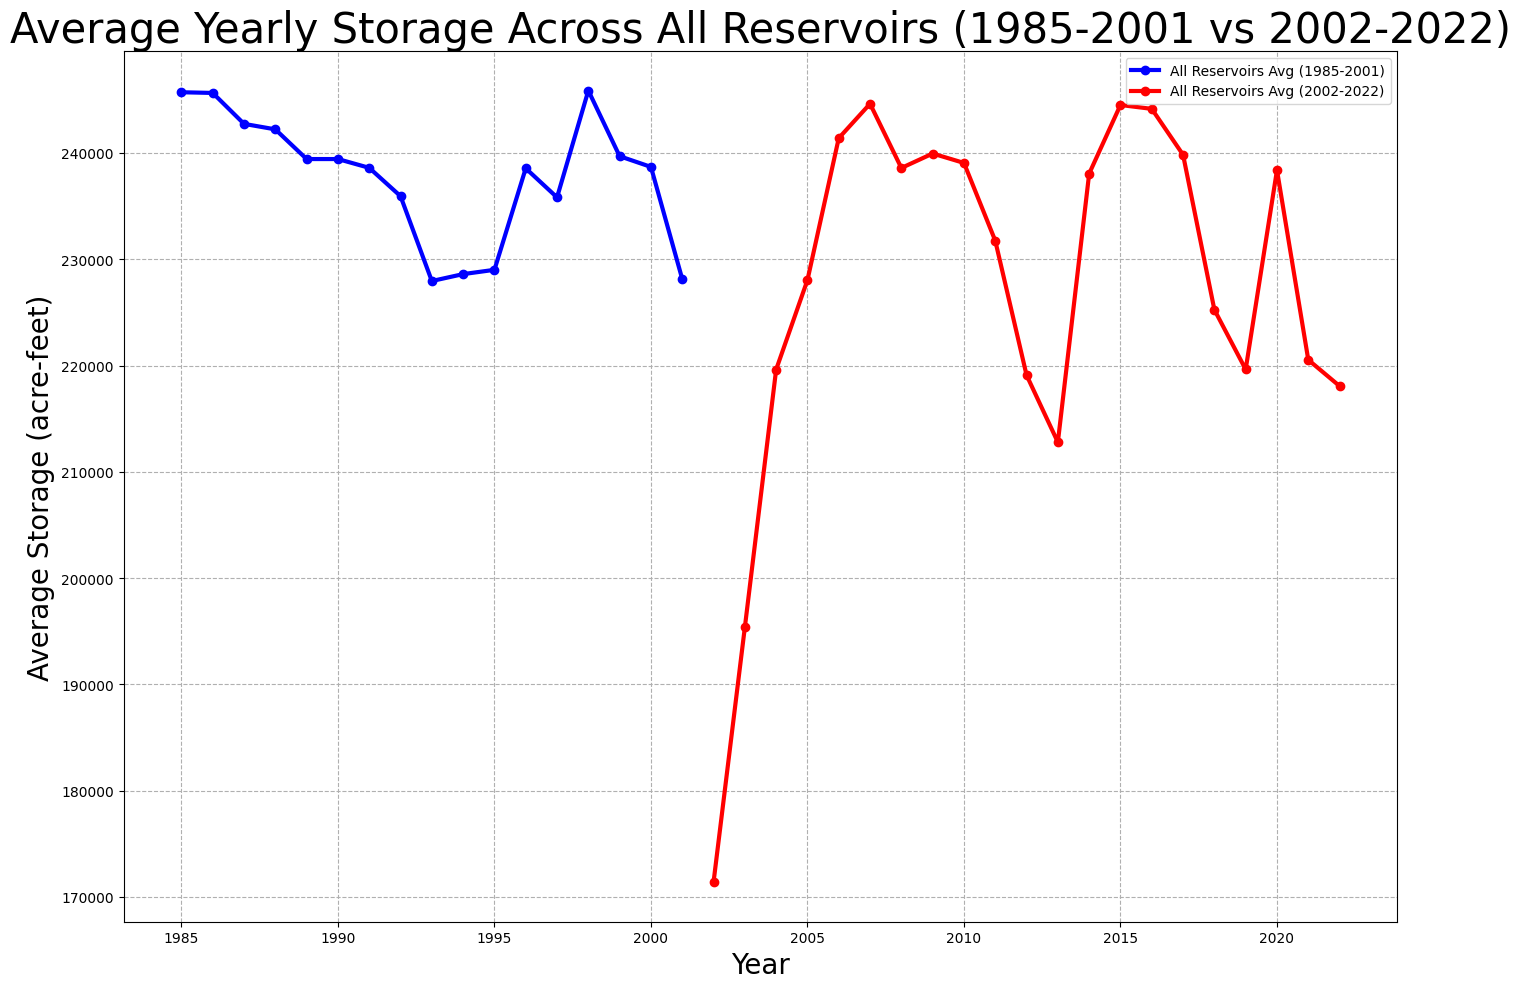

In [ ]:
# Define the processing function
def process_reservoir(filepath, name):
    df = pd.read_csv(filepath)
    df = df[['Date', 'Storage (af)']]
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Storage (af)'] = pd.to_numeric(df['Storage (af)'], errors='coerce')
    df = df.dropna()
    df['Year'] = df['Date'].dt.year
    yearly_avg = df.groupby('Year')['Storage (af)'].mean().reset_index()
    yearly_avg.rename(columns={'Storage (af)': name}, inplace=True)
    return yearly_avg

# Process all reservoirs
reservoirs = {
    'Dillon': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Dillon Reservoir.csv',
    'Blue Mesa': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Blue Mesa Reservoir.csv',
    'Granby': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Granby Reservoir.csv',
    'Green Mountain': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Green Mountain Reservoir.csv',
    'Morrow Point': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Morrow Point Reservoir.csv',
    'Navajo': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Navajo Reservoir.csv',
    'Ruedi': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Ruedi Reservoir.csv',
    'Taylor Park': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Taylor Park Reservoir.csv',
    'Vallecito': '/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Vallecito Reservoir.csv',
}

# Process and store each yearly average DataFrame
dfs = []
for name, path in reservoirs.items():
    df = process_reservoir(path, name)
    dfs.append(df)

# Merge all reservoirs on 'Year'
from functools import reduce
merged = reduce(lambda left, right: pd.merge(left, right, on='Year', how='outer'), dfs)
merged = merged.sort_values('Year')

# Calculate average storage across all reservoirs
merged['All Reservoirs Average'] = merged.iloc[:, 1:].mean(axis=1)

# Separate data for 1985-2001
merged_1985_2001 = merged[(merged['Year'] >= 1985) & (merged['Year'] <= 2001)].copy()

# Separate data for 2002-2022
merged_2002_2022 = merged[(merged['Year'] >= 2002) & (merged['Year'] <= 2022)].copy()

plt.figure(figsize=(14, 10))

# Plot the average line for 1985-2001
plt.plot(
    merged_1985_2001['Year'],
    merged_1985_2001['All Reservoirs Average'],
    marker='o',
    color='blue',
    linewidth=3,
    label='All Reservoirs Avg (1985-2001)'
)

# Plot the average line for 2002-2022
plt.plot(
    merged_2002_2022['Year'],
    merged_2002_2022['All Reservoirs Average'],
    marker='o',
    color='red',
    linewidth=3,
    label='All Reservoirs Avg (2002-2022)'
)

# Titles and labels
plt.title('Average Yearly Storage Across All Reservoirs (1985-2001 vs 2002-2022)', fontsize=30)
plt.xlabel('Year', fontsize=20)
plt.ylabel('Average Storage (acre-feet)', fontsize=20)

# Legend
plt.legend()

# Grid and layout
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# Install Plotly if not already installed
%pip install plotly

In [ ]:
import plotly.graph_objects as go

# Create a Plotly figure
fig = go.Figure()

# Add the average line for 1985-2001
fig.add_trace(go.Scatter(
    x=merged_1985_2001['Year'],
    y=merged_1985_2001['All Reservoirs Average'],
    mode='lines+markers',
    name='All Reservoirs Avg (1985-2001)',
    line=dict(color='blue', width=3),
    marker=dict(size=8)
))

# Add the average line for 2002-2022
fig.add_trace(go.Scatter(
    x=merged_2002_2022['Year'],
    y=merged_2002_2022['All Reservoirs Average'],
    mode='lines+markers',
    name='All Reservoirs Avg (2002-2022)',
    line=dict(color='red', width=3),
    marker=dict(size=8)
))

# Update layout
fig.update_layout(
    title='Yearly Averages of Colorado’s Largest Upper Basin Reservoirs<br>(1985–2001 vs. 2002–2022)',
    xaxis_title='Year',
    yaxis_title='Average Storage (acre-feet)',
    legend=dict(x=0.99, y=0.01, xanchor='right', yanchor='bottom'),
    hovermode='x unified',
    title_font_size=30,
    xaxis_title_font_size=20,
    yaxis_title_font_size=20
)

# Show the plot
fig.show()

# Save the plot as an HTML file
fig.write_html("average_yearly_storage_1985_2022.html")

/tmp/ipython-input-28-2938298405.py:5: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



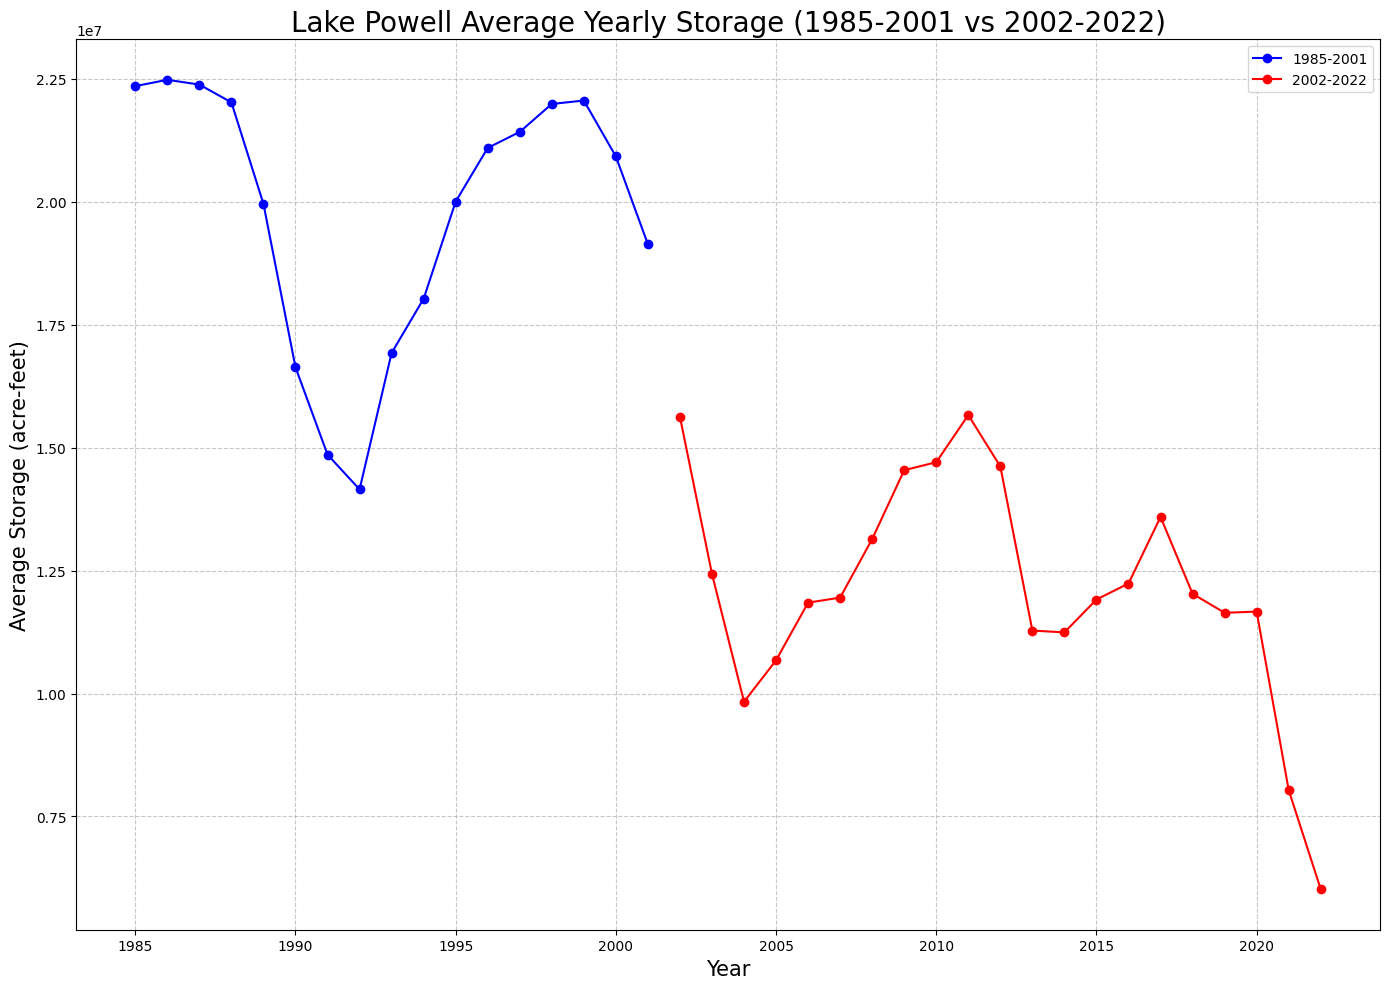

In [ ]:
# Define the filepath for Lake Powell data
lake_powell_filepath = "/content/drive/MyDrive/ESIIL Project Data/Reservoir Data/Lake Powell.csv"

# Process the Lake Powell data using the existing function
lake_powell_yearly_avg = process_reservoir(lake_powell_filepath, 'Lake Powell')

# Separate data for 1985-2001
lake_powell_1985_2001 = lake_powell_yearly_avg[(lake_powell_yearly_avg['Year'] >= 1985) & (lake_powell_yearly_avg['Year'] <= 2001)].copy()

# Separate data for 2002-2022
lake_powell_2002_2022 = lake_powell_yearly_avg[(lake_powell_yearly_avg['Year'] >= 2002) & (lake_powell_yearly_avg['Year'] <= 2022)].copy()

# Create a single plot for Lake Powell yearly average storage using Matplotlib
plt.figure(figsize=(14, 10))

# Plot for 1985-2001
plt.plot(lake_powell_1985_2001['Year'], lake_powell_1985_2001['Lake Powell'], marker='o', linestyle='-', color='blue', label='1985-2001')

# Plot for 2002-2022
plt.plot(lake_powell_2002_2022['Year'], lake_powell_2002_2022['Lake Powell'], marker='o', linestyle='-', color='red', label='2002-2022')

plt.title('Lake Powell Average Yearly Storage (1985-2001 vs 2002-2022)', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Average Storage (acre-feet)', fontsize=15)
plt.legend(loc='upper right') # Move legend to upper right
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Create a Plotly figure
fig_powell = go.Figure()

# Add the line for Lake Powell yearly average storage (1985-2001)
fig_powell.add_trace(go.Scatter(
    x=lake_powell_1985_2001['Year'],
    y=lake_powell_1985_2001['Lake Powell'],
    mode='lines+markers',
    name='1985-2001',
    line=dict(color='blue', width=3),
    marker=dict(size=8)
))

# Add the line for Lake Powell yearly average storage (2002-2022)
fig_powell.add_trace(go.Scatter(
    x=lake_powell_2002_2022['Year'],
    y=lake_powell_2002_2022['Lake Powell'],
    mode='lines+markers',
    name='2002-2022',
    line=dict(color='red', width=3),
    marker=dict(size=8)
))

# Update layout for Lake Powell plot
fig_powell.update_layout(
    title='Lake Powell Average Yearly Storage (1985-2001 vs 2002-2022)',
    xaxis_title='Year',
    yaxis_title='Average Storage (acre-feet)',
    hovermode='x unified',
    title_font_size=30,
    xaxis_title_font_size=20,
    yaxis_title_font_size=20,
    legend=dict(x=0.99, y=0.99, xanchor='right', yanchor='top') # Move legend to top right
)

# Show the Lake Powell plot
fig_powell.show()

# Save the Lake Powell plot as an HTML file
fig_powell.write_html("lake_powell_yearly_average_storage_combined.html")